Lendo dados da máquina 'fan' - Seção 'section_00'...


Extraindo Avaliação: 100%|██████████| 200/200 [00:02<00:00, 97.09it/s]



INICIANDO GRID SEARCH MASSIVO (FINE-TUNING)
Testando 90 combinações para o One-Class SVM...


OCSVM Grid: 100%|██████████| 90/90 [00:05<00:00, 15.38it/s] 


-> Melhor OCSVM AUC-Val: 81.00% | Params: {'gamma': 0.1, 'kernel': 'sigmoid', 'nu': 0.1}

Testando 216 combinações para o Isolation Forest...


iForest Grid: 100%|██████████| 216/216 [01:21<00:00,  2.65it/s]


-> Melhor Isolation Forest AUC-Val: 82.32% | Params: {'contamination': 'auto', 'max_features': 1.0, 'max_samples': 0.8, 'n_estimators': 500}

AVALIAÇÃO NO CONJUNTO DE TESTE FINAL (INTOCADO)

[1] RESULTADOS: Melhor One-Class SVM
ROC-AUC Teste: 76.88%
Relatório de Classificação:
              precision    recall  f1-score   support

  Normal (0)       0.69      0.80      0.74        50
Anomalia (1)       0.76      0.64      0.70        50

    accuracy                           0.72       100
   macro avg       0.73      0.72      0.72       100
weighted avg       0.73      0.72      0.72       100


[2] RESULTADOS: Melhor Isolation Forest
ROC-AUC Teste: 82.92%
Relatório de Classificação:
              precision    recall  f1-score   support

  Normal (0)       0.70      0.92      0.79        50
Anomalia (1)       0.88      0.60      0.71        50

    accuracy                           0.76       100
   macro avg       0.79      0.76      0.75       100
weighted avg       0.79      0.7

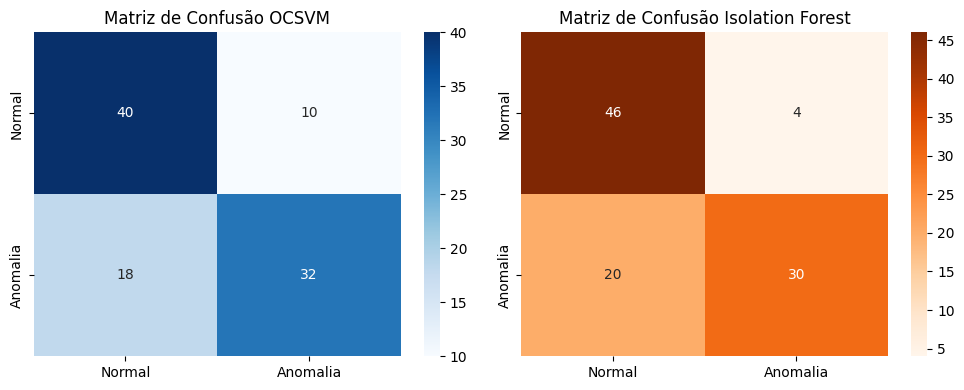


--- Gerando Explicabilidade (SHAP) para o Isolation Forest Vencedor ---


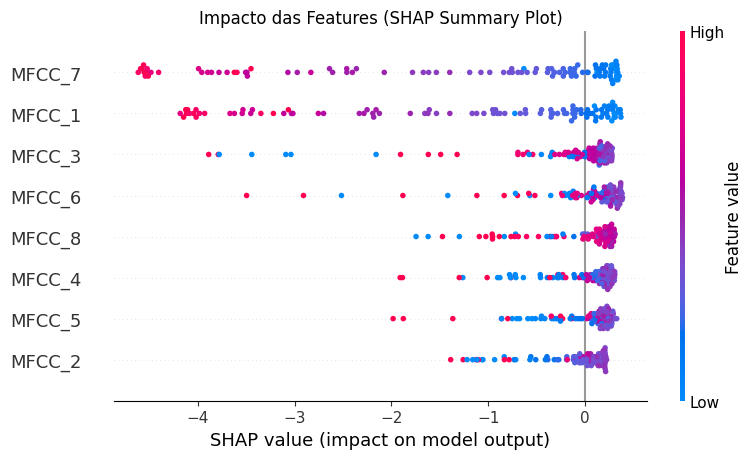

In [9]:
import os
from pathlib import Path
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import scipy.stats

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import shap
from sklearn.model_selection import train_test_split, ParameterGrid

# =====================================================================
# 1. PARÂMETROS
# =====================================================================
SAMPLE_RATE = 16000
# ATENÇÃO: Verifique o seu caminho
DCASE2022_DEV_PATH = Path(r"C:\Users\josel\OneDrive\Desktop\NCIA\data\raw\dcase-2024\Dev") 
MACHINE_TYPE = 'fan'
TARGET_SECTION = 'section_00'

# =====================================================================
# 2. FEATURE EXTRACTION (Baseado estritamente no Artigo)
# =====================================================================
def extract_paper_features(file_path):
    signal, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)
    
    # --- Feature 1: MFCCs (128 dimensões, média no tempo) ---
    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=128)
    mfccs_mean = np.mean(mfccs, axis=1)  
    
    # --- Feature 2: Basic Audio Features (8 métricas estatísticas) ---
    rms = np.sqrt(np.mean(signal**2))
    kurt = scipy.stats.kurtosis(signal)
    skew = scipy.stats.skew(signal)
    p2p = np.ptp(signal) 
    crest = np.max(np.abs(signal)) / (rms + 1e-8) 
    mean_val = np.mean(signal)
    std_val = np.std(signal)
    
    hist, _ = np.histogram(signal, bins=256, density=True)
    hist = hist[hist > 0]
    entropy = scipy.stats.entropy(hist)
    
    basic_features = np.array([rms, kurt, skew, p2p, crest, mean_val, std_val, entropy])
    return np.concatenate([basic_features])

feature_names = [f"MFCC_{i}" for i in range(1, 129)] + \
                ["RMS", "Kurtosis", "Skewness", "Peak-to-Peak", "Crest_Factor", "Mean", "Std", "Entropy"]

# =====================================================================
# 3. LEITURA E SEPARAÇÃO DOS DADOS
# =====================================================================
print(f"Lendo dados da máquina '{MACHINE_TYPE}' - Seção '{TARGET_SECTION}'...")

X_train_raw, y_train_raw = [], []
X_teste_completo, y_teste_completo = [], []
machine_dir = DCASE2022_DEV_PATH / MACHINE_TYPE

for f in tqdm(list((machine_dir / 'train').rglob('*.wav')), desc="Extraindo Treino"):
    if TARGET_SECTION in f.name:
        X_train_raw.append(extract_paper_features(f))
        y_train_raw.append(0)

for f in tqdm(list((machine_dir / 'test').rglob('*.wav')), desc="Extraindo Avaliação"):
    if TARGET_SECTION in f.name:
        X_teste_completo.append(extract_paper_features(f))
        label = 1 if 'anomaly' in f.name else 0
        y_teste_completo.append(label)

if len(X_train_raw) == 0:
    raise ValueError(f"Nenhum arquivo encontrado em {machine_dir}. Verifique o caminho!")

X_train_raw = np.array(X_train_raw)
y_train_raw = np.array(y_train_raw)

# Dividir Avaliação em Validação (Fine-Tuning) e Teste Final
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_teste_completo, y_teste_completo, test_size=0.5, random_state=42, stratify=y_teste_completo
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

# =====================================================================
# 4. EXHAUSTIVE GRID SEARCH (No Conjunto de Validação)
# =====================================================================
print("\n" + "="*50)
print("INICIANDO GRID SEARCH MASSIVO (FINE-TUNING)")
print("="*50)

# --- ESPAÇO DE BUSCA OCSVM (90 combinações) ---
param_grid_ocsvm = {
    'nu': [0.001, 0.01, 0.05, 0.1, 0.2],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 0.5],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

melhor_auc_ocsvm = 0
melhor_ocsvm = None
melhores_params_ocsvm = {}

grid_ocsvm = list(ParameterGrid(param_grid_ocsvm))
print(f"Testando {len(grid_ocsvm)} combinações para o One-Class SVM...")

for params in tqdm(grid_ocsvm, desc="OCSVM Grid"):
    ocsvm = OneClassSVM(**params)
    ocsvm.fit(X_train_scaled)
    scores_val = -ocsvm.decision_function(X_val_scaled)
    auc_val = roc_auc_score(y_val, scores_val)
    
    if auc_val > melhor_auc_ocsvm:
        melhor_auc_ocsvm = auc_val
        melhor_ocsvm = ocsvm
        melhores_params_ocsvm = params

print(f"-> Melhor OCSVM AUC-Val: {melhor_auc_ocsvm:.2%} | Params: {melhores_params_ocsvm}")

# --- ESPAÇO DE BUSCA ISOLATION FOREST (216 combinações) ---
param_grid_if = {
    'n_estimators': [100, 300, 500, 1000],
    'max_samples': ['auto', 0.5, 0.8],
    'contamination': ['auto', 0.01, 0.05, 0.1, 0.15, 0.2],
    'max_features': [0.5, 0.8, 1.0]
}

melhor_auc_if = 0
melhor_iforest = None
melhores_params_if = {}

grid_if = list(ParameterGrid(param_grid_if))
print(f"\nTestando {len(grid_if)} combinações para o Isolation Forest...")

for params in tqdm(grid_if, desc="iForest Grid"):
    iforest = IsolationForest(**params, random_state=42)
    iforest.fit(X_train_scaled)
    scores_val = -iforest.decision_function(X_val_scaled)
    auc_val = roc_auc_score(y_val, scores_val)
    
    if auc_val > melhor_auc_if:
        melhor_auc_if = auc_val
        melhor_iforest = iforest
        melhores_params_if = params

print(f"-> Melhor Isolation Forest AUC-Val: {melhor_auc_if:.2%} | Params: {melhores_params_if}")

# =====================================================================
# 5. TESTE FINAL (AVALIAÇÃO NO TEST SET INTOCADO)
# =====================================================================
print("\n" + "="*50)
print("AVALIAÇÃO NO CONJUNTO DE TESTE FINAL (INTOCADO)")
print("="*50)

# --- Teste do OCSVM ---
scores_test_ocsvm = -melhor_ocsvm.decision_function(X_test_scaled)
preds_test_ocsvm = [1 if x == -1 else 0 for x in melhor_ocsvm.predict(X_test_scaled)]
auc_test_ocsvm = roc_auc_score(y_test, scores_test_ocsvm)

print(f"\n[1] RESULTADOS: Melhor One-Class SVM")
print(f"ROC-AUC Teste: {auc_test_ocsvm:.2%}")
print("Relatório de Classificação:")
print(classification_report(y_test, preds_test_ocsvm, target_names=['Normal (0)', 'Anomalia (1)'], zero_division=0))

# --- Teste do Isolation Forest ---
scores_test_if = -melhor_iforest.decision_function(X_test_scaled)
preds_test_if = [1 if x == -1 else 0 for x in melhor_iforest.predict(X_test_scaled)]
auc_test_if = roc_auc_score(y_test, scores_test_if)

print(f"\n[2] RESULTADOS: Melhor Isolation Forest")
print(f"ROC-AUC Teste: {auc_test_if:.2%}")
print("Relatório de Classificação:")
print(classification_report(y_test, preds_test_if, target_names=['Normal (0)', 'Anomalia (1)'], zero_division=0))

# =====================================================================
# 6. MATRIZES DE CONFUSÃO VISUAIS
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_ocsvm = confusion_matrix(y_test, preds_test_ocsvm)
sns.heatmap(cm_ocsvm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Normal', 'Anomalia'], yticklabels=['Normal', 'Anomalia'])
axes[0].set_title(f'Matriz de Confusão OCSVM')

cm_if = confusion_matrix(y_test, preds_test_if)
sns.heatmap(cm_if, annot=True, fmt='d', cmap='Oranges', ax=axes[1], xticklabels=['Normal', 'Anomalia'], yticklabels=['Normal', 'Anomalia'])
axes[1].set_title(f'Matriz de Confusão Isolation Forest')

plt.tight_layout()
plt.show()

# =====================================================================
# 7. EXPLICABILIDADE AVANÇADA COM SHAP
# =====================================================================
print("\n--- Gerando Explicabilidade (SHAP) para o Isolation Forest Vencedor ---")
explainer = shap.TreeExplainer(melhor_iforest)
shap_values = explainer.shap_values(X_test_scaled)

plt.figure(figsize=(10, 6))
plt.title(f"Impacto das Features (SHAP Summary Plot)")
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
shap.summary_plot(sv, X_test_scaled, feature_names=feature_names)